In [1]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, Omega1, Omega2):

    y = Y[:4]
    v = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, Omega1, Omega2)
    M = jacobian(t, y, Omega1, Omega2)

    dv_raw = M @ v
    W = np.dot(v, dv_raw)

    dv = dv_raw - W*v
    dZ = t*W

    return np.concatenate((dy, dv, [dZ]))

def megno_dynamics(Omega1, Omega2):

    megno_values = []

    for i, (q0, p0, X0, P0) in enumerate(initial_conditions):

        v0 = np.array([1.0, 0.0, 0.0, 0.0])

        Y0 = np.concatenate(([q0, p0, X0, P0], v0, [0.0]))

        sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=T/20)

        if sol.success:
            Z = sol.y[8]
            Y_megno = np.zeros_like(sol.t)
            Y_megno[1:] = 2*Z[1:]/sol.t[1:]
            megno_final = Y_megno[-1]
        else:
            megno_final = np.nan  # or some other value indicating failure    

        megno_values.append(megno_final)

        

    return np.array(megno_values)

def chaotic_energy(Omega1, Omega2, chaotic_indices):

    energies = []

    for i in chaotic_indices:

        q0, p0, X0, P0 = initial_conditions[i]

        sol = solve_ivp(equations, (0, n_periods*T), [q0, p0, X0, P0], args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-9, atol=1e-11, max_step=T/20)

        if sol.success:

            X = sol.y[2]
            P = sol.y[3]

            E = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)

        else:

            print(f"Energy integration failed for IC {i+1}: {sol.message}")
            E = np.full(len(tlist), np.nan)

        energies.append(E)

    return np.array(energies)

Running Omega1 = 0, Omega2 = 0
Number of chaotic ICs: 9
Chaotic IC numbers: [ 2  9 10 24 29 61 63 94 98]

Omega1 = 0, Omega2 = 0
Number of chaotic ICs = 9
Slope = -3.200398750516375
R² = 0.9019511387686938
Effective beta = 3.200398750516375
Effective temperature = 0.31246106437163584
Running Omega1 = 2.5, Omega2 = 2.0
Number of chaotic ICs: 25
Chaotic IC numbers: [ 4  6  9 18 22 24 25 38 40 41 43 45 46 52 57 59 61 62 64 74 85 87 90 96
 98]


/tmp/ipykernel_14956/2551260516.py:9: RuntimeWarning: invalid value encountered in sqrt
  A = np.sqrt(A2)



Omega1 = 2.5, Omega2 = 2.0
Number of chaotic ICs = 25
Slope = -1.5237968558967192
R² = 0.9042150534223976
Effective beta = 1.5237968558967192
Effective temperature = 0.6562554556601464


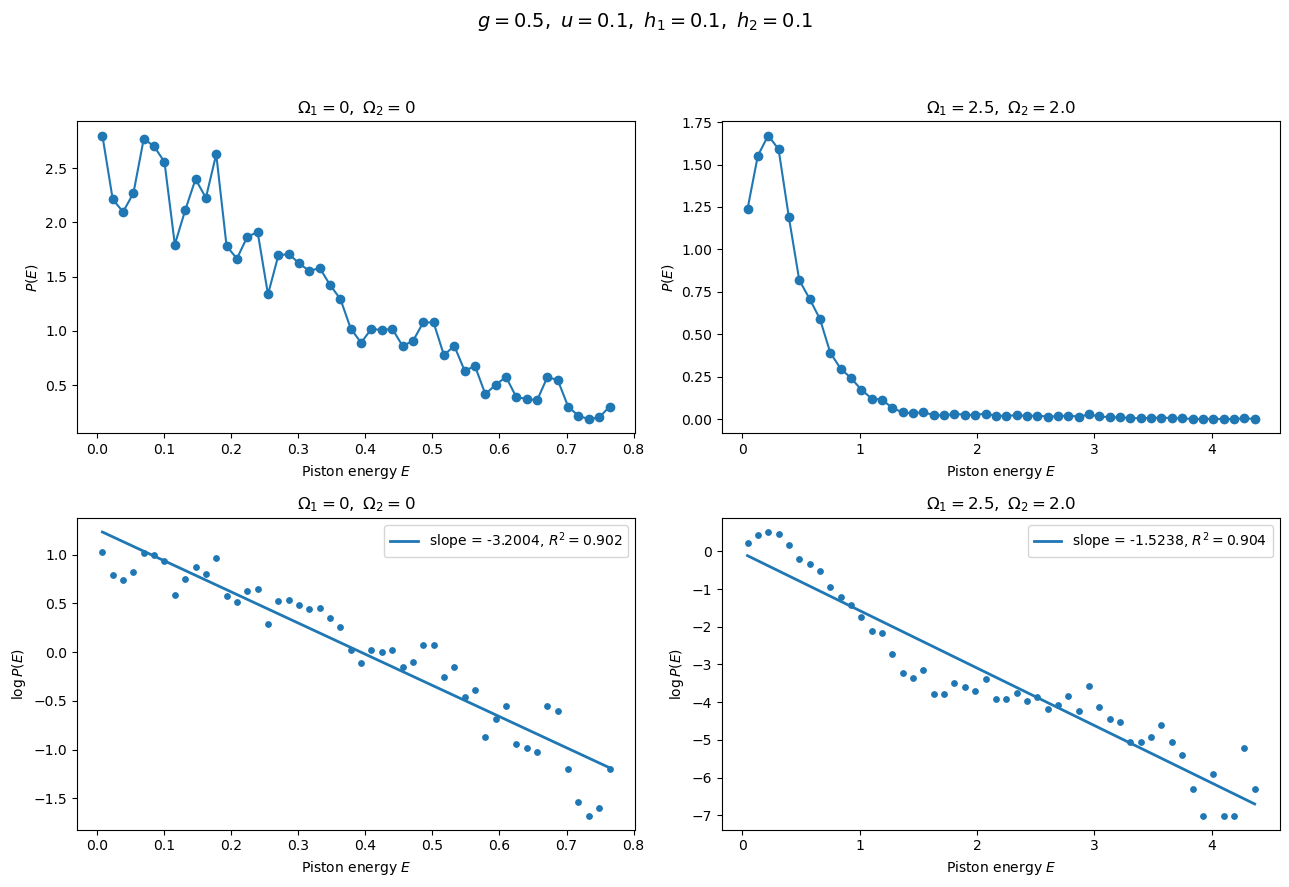

In [2]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt


J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1

frequency_sets = [(0, 0), (2.5, 2.0)]
megno_threshold = 10

n_initial = 100
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

os.makedirs("megno_data", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    print(f"Running Omega1 = {Omega1}, Omega2 = {Omega2}")

    megno_values = megno_dynamics(Omega1, Omega2)

    chaotic_indices = np.where(megno_values > megno_threshold)[0]
    print(f"Number of chaotic ICs: {len(chaotic_indices)}")
    print("Chaotic IC numbers:", chaotic_indices + 1)

    energies = chaotic_energy(Omega1, Omega2, chaotic_indices)
    E_all = energies.ravel()
    E_all = E_all[np.isfinite(E_all)]

    #filename = f"MEGNO_Final_IC_2nd_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    #filepath = os.path.join("megno_data", filename)
    #np.savez(filepath, initial_conditions=initial_conditions, megno_values=megno_values, chaotic_indices=chaotic_indices, chaotic_energies=energies)

     # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    axes[1, k].legend()

    print()
    print(f"Omega1 = {Omega1}, Omega2 = {Omega2}")
    print(f"Number of chaotic ICs = {len(energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")

fig.suptitle(rf"$g={g},\ u={u},\ h_1={h1},\ h_2={h2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("megno_data/piston_energy_distribution_v_vector.png", dpi=300, bbox_inches="tight")
plt.show()


$rtol = e^{-8}, atol = e^{-10}$

In [2]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, Omega1, Omega2):

    y = Y[:4]
    v = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, Omega1, Omega2)
    M = jacobian(t, y, Omega1, Omega2)
    
    dv_raw = M @ v
    W = np.dot(v, dv_raw)

    dv = dv_raw - W*v
    dZ = t*W

    return np.concatenate((dy, dv, [dZ]))

def megno_dynamics(args):
   
    Omega1 = args["Omega1"]
    Omega2 = args["Omega2"]
    ic = args["ic"]
    q0, p0, X0, P0 = ic
    
    v0 = np.array([1.0, 0.0, 0.0, 0.0])
    Y0 = np.concatenate(([q0, p0, X0, P0], v0, [0.0]))

    sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-8, atol=1e-10, max_step=0.02)

    if sol.success:
        X = sol.y[2]
        P = sol.y[3]
        energies = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)
        Z = sol.y[8]
        Y_megno = np.zeros_like(sol.t)
        Y_megno[1:] = 2*Z[1:]/sol.t[1:]
        megno_final = Y_megno[-1]
    else:
        v = sol.y[4:8]
        v_norm = np.linalg.norm(v, axis=0)
        q = sol.y[0]
        p = sol.y[1]
        A2 = 2.0 - q**2 - p**2

        print(f"Integration failed at t={sol.t[-1]:.6f}, "
        f"minimum A2={np.min(A2):.6e}, "
        f"minimum |v| = {np.min(v_norm):.6e}, "
        f"maximum |v| = {np.max(v_norm):.6e}, "
        f"message={sol.message}")
        
        energies = np.full(len(tlist), np.nan)
        megno_final = np.nan  # or some other value indicating failure    

    return megno_final , energies


Running Omega1 = 0, Omega2 = 0
Number of chaotic ICs: 9
Chaotic IC numbers: [ 2  9 10 24 29 61 63 94 98]

Slope = -3.163670103676399
R² = 0.9165346155458989
Effective beta = 3.163670103676399
Effective temperature = 0.3160885829524173
---------------------------------
Running Omega1 = 2.5, Omega2 = 2.0
Number of chaotic ICs: 25
Chaotic IC numbers: [ 4  6  9 18 22 24 25 38 40 41 43 45 46 52 57 59 61 62 64 74 85 87 90 96
 98]

Slope = -1.9062163648211377
R² = 0.9677194608345152
Effective beta = 1.9062163648211377
Effective temperature = 0.524599420325421
---------------------------------


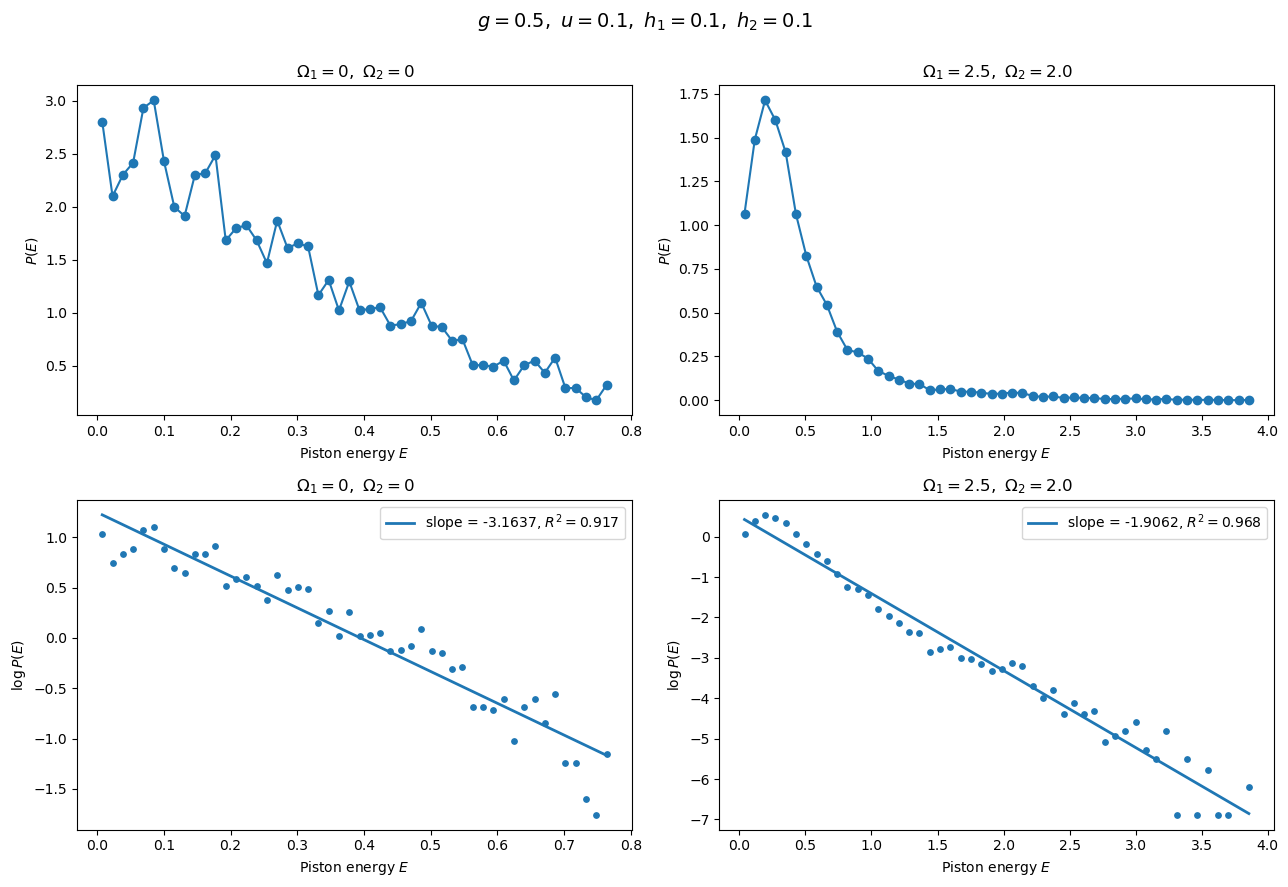

In [3]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
from multiprocessing import Pool

J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1
frequency_sets = [(0, 0), (2.5, 2.0)]
megno_threshold = 10
n_initial = 100
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

os.makedirs("megno_data", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    args = [{"Omega1": Omega1, "Omega2": Omega2, "ic": ic} for ic in initial_conditions]

    with Pool(processes=4) as pool:
        print(f"Running Omega1 = {Omega1}, Omega2 = {Omega2}")

        results = pool.map(megno_dynamics, args)

        megno_values = np.array([result[0] for result in results])
        energies = np.array([result[1] for result in results])

        # megno_values = results[:, 0]
        # energies = results[:, 1]

        chaotic_indices = np.where(megno_values > megno_threshold)[0]
        print(f"Number of chaotic ICs: {len(chaotic_indices)}")
        print("Chaotic IC numbers:", chaotic_indices + 1)

        chaotic_energies = energies[chaotic_indices]
        E_all = chaotic_energies.ravel()
        E_all = E_all[np.isfinite(E_all)]

    # filename = f"MEGNO_Final_IC_2nd_multiprocess_norm_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    # filepath = os.path.join("megno_data", filename)
    # np.savez(filepath, initial_conditions=initial_conditions, megno_values=megno_values, chaotic_indices=chaotic_indices, chaotic_energies=chaotic_energies)

     # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\,\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\,\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    axes[1, k].legend()

    print()
    #print(f"h1 = {h1}, h2 = {h2}")
    #print(f"Number of chaotic ICs = {len(chaotic_energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")
        print("---------------------------------")

fig.suptitle(rf"$g={g},\ u={u},\ h_1={h1},\ h_2={h2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f"megno_data/t_piston_energy_distribution_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_u_{u}.png", dpi=300, bbox_inches="tight")
plt.show()

$h_1 = 1, h_2 = 0.001, \Omega_1 = 0.7, \Omega_2 = 100$ 

$h_1 = 0.001, h_2 = 60.12, \Omega_1 = 0.7, \Omega_2 = 100$

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, h1, h2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, h1, h2):

    y = Y[:4]
    v = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, h1, h2)
    M = jacobian(t, y, h1, h2)
    
    dv_raw = M @ v
    W = np.dot(v, dv_raw)

    dv = dv_raw - W*v
    dZ = t*W

    return np.concatenate((dy, dv, [dZ]))

def megno_dynamics(args):
   
    h1 = args["h1"]
    h2 = args["h2"]
    i = args["i"]
    ic = args["ic"]
    q0, p0, X0, P0 = ic
    
    v0 = np.array([1.0, 0.0, 0.0, 0.0])
    Y0 = np.concatenate(([q0, p0, X0, P0], v0, [0.0]))

    sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(h1, h2), method="DOP853", t_eval=tlist, rtol=1e-8, atol=1e-10, max_step=0.01)

    if sol.success:
        X = sol.y[2]
        P = sol.y[3]
        energies = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)
        Z = sol.y[8]
        Y_megno = np.zeros_like(sol.t)
        Y_megno[1:] = 2*Z[1:]/sol.t[1:]
        megno_final = Y_megno[-1]
    else:
        v = sol.y[4:8]
        v_norm = np.linalg.norm(v, axis=0)
        q = sol.y[0]
        p = sol.y[1]
        A2 = 2.0 - q**2 - p**2

        print(f"Integration failed at t={sol.t[-1]:.6f}, "
        f"minimum A2={np.min(A2):.6e}, "
        f"minimum |v| = {np.min(v_norm):.6e}, "
        f"maximum |v| = {np.max(v_norm):.6e}, "
        f"message={sol.message}")
        
        energies = np.full(len(tlist), np.nan)
        megno_final = np.nan  # or some other value indicating failure    

    return megno_final , energies, i, sol.success


In [ ]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
from multiprocessing import Pool

if __name__ == "__main__":
    os.makedirs("megno_data", exist_ok=True)
    os.makedirs("megno_plots", exist_ok=True)

    J = 1.0
    Omega1 = 0.7
    Omega2 = 100.0
    g = 0.5
    omega_p = 2.5
    u = 0.1

    hs = [(1, 0.001), (0.001, 60.12)]
    megno_threshold = 10

    n_initial = 100
    n_periods = 500
    T = 20*np.pi
    tlist = np.linspace(0, n_periods*T, n_periods + 1)

    rng = np.random.default_rng(12345)

    initial_conditions = []

    for i in range(n_initial):
        q0 = rng.uniform(-0.90, 0.90)
        p0 = rng.uniform(-0.90, 0.90)
        X0 = rng.uniform(-0.50, 0.50)
        P0 = rng.uniform(-0.50, 0.50)
        initial_conditions.append([q0, p0, X0, P0])

    initial_conditions = np.array(initial_conditions)


    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    for k, (h1, h2) in enumerate(hs):

        args = [{"h1": h1, "h2": h2, "i":i, "ic": ic} for i, ic in enumerate(initial_conditions)]

        with Pool(processes=4) as pool:

            print(f"Running h1 = {h1}, h2 = {h2}")
            results = pool.map(megno_dynamics, args)
            megno_values = np.array([result[0] for result in results])
            energies = np.array([result[1] for result in results])

            failed_indices = [result[2] for result in results if not result[3]]
            print("Failed IC numbers:", np.array(failed_indices)+1)

            chaotic_indices = np.where(np.isfinite(megno_values) & (megno_values > megno_threshold))[0]
            print(f"Number of chaotic ICs: {len(chaotic_indices)}")
            print("Chaotic IC numbers:", chaotic_indices + 1)

            chaotic_energies = energies[chaotic_indices]
            E_all = chaotic_energies.ravel()
            E_all = E_all[np.isfinite(E_all)]

        filename = f"megno_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_u_{u}_g_{g}_h1_{h1}_h2_{h2}.npz"
        np.savez(f"megno_data/{filename}", initial_conditions=initial_conditions, failed_indices=failed_indices, megno_values=megno_values, energies=energies)

        # Energy distribution
        counts, bins = np.histogram(E_all, bins=50, density=True)
        E_centers = 0.5*(bins[:-1] + bins[1:])

        axes[0, k].plot(E_centers, counts, "o-")
        axes[0, k].set_xlabel("Piston energy $E$")
        axes[0, k].set_ylabel("$P(E)$")
        axes[0, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

        # log P(E)
        mask = counts > 0

        E_fit = E_centers[mask]
        log_P = np.log(counts[mask])

        fit = linregress(E_fit, log_P)

        slope = fit.slope
        intercept = fit.intercept
        R2 = fit.rvalue**2

        axes[1, k].scatter(E_fit, log_P, s=15)

        axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

        axes[1, k].set_xlabel("Piston energy $E$")
        axes[1, k].set_ylabel(r"$\log P(E)$")
        axes[1, k].set_title(rf"$\,h_1={h1},\ h_2={h2}$")

        axes[1, k].legend()

        print()
        #print(f"h1 = {h1}, h2 = {h2}")
        #print(f"Number of chaotic ICs = {len(chaotic_energies)}")
        print(f"Slope = {slope}")
        print(f"R² = {R2}")

        if slope < 0:
            beta = -slope
            T_eff = 1/beta

            print(f"Effective beta = {beta}")
            print(f"Effective temperature = {T_eff}")
            print("---------------------------------")

    fig.suptitle(rf"$g={g},\ u={u},\Omega1={Omega1},\Omega2={Omega2}$", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(f"megno_plots/megno_piston_energy_distribution_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_u_{u}.png", dpi=300, bbox_inches="tight")
    plt.show()


$\Omega_1 = 2.5, \, \Omega_2 = 2.0, \ h_1 = h_2 = 0.1$

Modifying the normalized and multiprocess code for storing all the megno values at strobosocopic time to plot the time dynamics of megno for every initial conditions. I also modify the code slightly according to my understanding.(12/09/26)

In [3]:
import numpy as np
from scipy.integrate import solve_ivp

def equations(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    dq = (-J*p*(R2-1) + h1*c1*p*q/A - h2*c2*(A2-p**2)/A - g*P*A/np.sqrt(2) - g*p*D/(np.sqrt(2)*A))
    dp = (J*q*(R2-1) + h1*c1*(A2-q**2)/A - h2*c2*p*q/A - g*X*A/np.sqrt(2) + g*q*D/(np.sqrt(2)*A))
    dX = (omega_p*P - (u/2)*(X**2+P**2)*P - g*p*A/np.sqrt(2))
    dP = (-omega_p*X + (u/2)*(X**2+P**2)*X - g*q*A/np.sqrt(2))

    return np.array([dq, dp, dX, dP])

def jacobian(t, y, Omega1, Omega2):

    q, p, X, P = y
    R2 = q**2 + p**2
    A2 = 2.0 - R2
    A = np.sqrt(A2)
    D = X*q - P*p
    C = D/A

    c1 = np.cos(Omega1*t)
    c2 = np.cos(Omega2*t)

    Cq = X/A + D*q/A**3
    Cp = -P/A + D*p/A**3

    J11 = (-2*J*p*q + h1*c1*(p/A + p*q**2/A**3) + h2*c2*(q/A + p**2*q/A**3) + g*P*q/(np.sqrt(2)*A) - g*p*Cq/np.sqrt(2))

    J12 = (-J*(R2-1+2*p**2) + h1*c1*(q/A + p**2*q/A**3) + h2*c2*(3*p/A + p**3/A**3) + g*P*p/(np.sqrt(2)*A) - g*p*Cp/np.sqrt(2) - g*D/(np.sqrt(2)*A))

    J13 = -g*p*q/(np.sqrt(2)*A)
    J14 = -g*A/np.sqrt(2) + g*p**2/(np.sqrt(2)*A)

    J21 = (J*(R2-1+2*q**2) - h1*c1*(3*q/A + q**3/A**3) - h2*c2*(p/A + p*q**2/A**3) + g*X*q/(np.sqrt(2)*A) + g*(C + q*Cq)/np.sqrt(2))

    J22 = (2*J*p*q - h1*c1*(p/A + q**2*p/A**3) - h2*c2*(q/A + p**2*q/A**3) + g*X*p/(np.sqrt(2)*A) + g*q*Cp/np.sqrt(2))

    J23 = -g*A/np.sqrt(2) + g*q**2/(np.sqrt(2)*A)
    J24 = -g*q*p/(np.sqrt(2)*A)

    J31 = g*p*q/(np.sqrt(2)*A)
    J32 = -g*(A - p**2/A)/np.sqrt(2)
    J33 = -u*X*P
    J34 = omega_p - (u/2)*(X**2 + 3*P**2)

    J41 = -g*(A - q**2/A)/np.sqrt(2)
    J42 = g*p*q/(np.sqrt(2)*A)
    J43 = -omega_p + (u/2)*(3*X**2 + P**2)
    J44 = u*X*P

    return np.array([
        [J11, J12, J13, J14],
        [J21, J22, J23, J24],
        [J31, J32, J33, J34],
        [J41, J42, J43, J44]
    ])

def megno_equations(t, Y, Omega1, Omega2):

    y = Y[:4]
    v = Y[4:8]
    Z = Y[8]

    dy = equations(t, y, Omega1, Omega2)
    M = jacobian(t, y, Omega1, Omega2)
    
    dv_raw = M @ v
    W = np.dot(v, dv_raw)

    dv = dv_raw - W*v
    dZ = t*W

    return np.concatenate((dy, dv, [dZ]))

def megno_dynamics(args):
   
    Omega1 = args["Omega1"]
    Omega2 = args["Omega2"]
    ic = args["ic"]
    #q0, p0, X0, P0 = ic
    
    v0 = np.array([1.0, 0.0, 0.0, 0.0])
    #Y0 = np.concatenate(([q0, p0, X0, P0], v0, [0.0]))
    Y0 = np.concatenate((ic, v0, [0.0]))

    sol = solve_ivp(megno_equations, (0, n_periods*T), Y0, args=(Omega1, Omega2), method="DOP853", t_eval=tlist, rtol=1e-8, atol=1e-10, max_step=T/20)

    if sol.success:
        X = sol.y[2]
        P = sol.y[3]
        energies = ((omega_p/2)*(X**2 + P**2) - (u/8)*(X**2 + P**2)**2)
        Z = sol.y[8]
        Y_megno = np.zeros_like(sol.t)
        Y_megno[1:] = 2*Z[1:]/sol.t[1:]
        megno_final = Y_megno[-1]
    else:
        v = sol.y[4:8]
        v_norm = np.linalg.norm(v, axis=0)
        q = sol.y[0]
        p = sol.y[1]
        A2 = 2.0 - q**2 - p**2

        print(f"Integration failed at t={sol.t[-1]:.6f}, "
        f"minimum A2={np.min(A2):.6e}, "
        f"minimum |v| = {np.min(v_norm):.6e}, "
        f"maximum |v| = {np.max(v_norm):.6e}, "
        f"message={sol.message}")
        
        Y_megno = np.full(len(tlist), np.nan)
        energies = np.full(len(tlist), np.nan)
        megno_final = np.nan  # or some other value indicating failure    

    return megno_final , energies, Y_megno


Running Omega1 = 0, Omega2 = 0
Number of chaotic ICs: 9
Chaotic IC numbers: [ 2  9 10 24 29 61 63 94 98]

Slope = -3.1878929296575
R² = 0.907753160311075
Effective beta = 3.1878929296575
Effective temperature = 0.3136868213787336
---------------------------------
Running Omega1 = 2.5, Omega2 = 2.0
Number of chaotic ICs: 26
Chaotic IC numbers: [ 4  6  9 18 22 24 25 38 40 41 43 45 46 52 57 59 61 62 64 74 85 87 89 90
 96 98]

Slope = -1.546130399307152
R² = 0.9331666048440362
Effective beta = 1.546130399307152
Effective temperature = 0.6467759772708158
---------------------------------


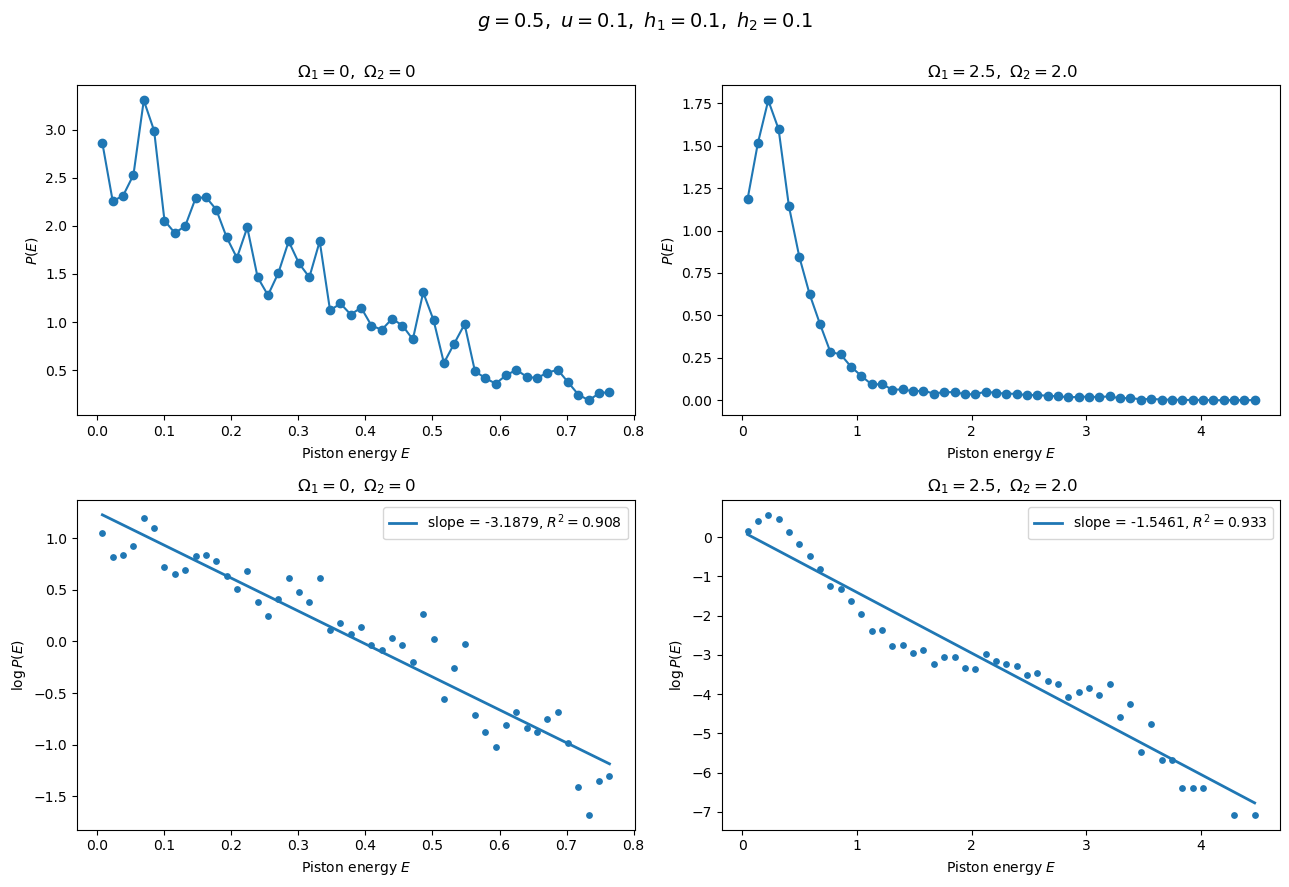

In [4]:
import os
from scipy.stats import linregress
import matplotlib.pyplot as plt
from multiprocessing import Pool

J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1
frequency_sets = [(0, 0), (2.5, 2.0)]
megno_threshold = 10
n_initial = 100
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)

rng = np.random.default_rng(12345)

initial_conditions = []

for i in range(n_initial):
    q0 = rng.uniform(-0.90, 0.90)
    p0 = rng.uniform(-0.90, 0.90)
    X0 = rng.uniform(-0.50, 0.50)
    P0 = rng.uniform(-0.50, 0.50)
    initial_conditions.append([q0, p0, X0, P0])

initial_conditions = np.array(initial_conditions)

os.makedirs("megno_data", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    args = [{"Omega1": Omega1, "Omega2": Omega2, "ic": ic} for ic in initial_conditions]

    with Pool(processes=4) as pool:
        print(f"Running Omega1 = {Omega1}, Omega2 = {Omega2}")

        results = pool.map(megno_dynamics, args)

        megno_values = np.array([result[0] for result in results])
        energies = np.array([result[1] for result in results])
        Y_megno = np.array([result[2] for result in results])

        chaotic_indices = np.where(megno_values > megno_threshold)[0]
        print(f"Number of chaotic ICs: {len(chaotic_indices)}")
        print("Chaotic IC numbers:", chaotic_indices + 1)

        chaotic_energies = energies[chaotic_indices]
        E_all = chaotic_energies.ravel()
        E_all = E_all[np.isfinite(E_all)]

    filename = f"m_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    filepath = os.path.join("megno_data", filename)
    np.savez(filepath, initial_conditions=initial_conditions, megno_values=megno_values, energies=energies, Y_megno=Y_megno)

     # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\,\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\,\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    axes[1, k].legend()

    print()
    #print(f"h1 = {h1}, h2 = {h2}")
    #print(f"Number of chaotic ICs = {len(chaotic_energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")
        print("---------------------------------")

fig.suptitle(rf"$g={g},\ u={u},\ h_1={h1},\ h_2={h2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f"megno_data/m_piston_energy_distribution_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_u_{u}.png", dpi=300, bbox_inches="tight")
plt.show()

Plotting Y[t]

In [ ]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1
frequency_sets = [(0, 0), (2.5, 2.0)]
megno_threshold = 10
n_initial = 100
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    filename = f"m_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    filepath = os.path.join("megno_data", filename)
    data = np.load(filepath)

    initial_conditions = data['initial_conditions']
    Y_megno = data['Y_megno']
    megno_values = data['megno_values']

    chaotic_indices = np.where(np.isfinite(megno_values) & (megno_values > megno_threshold))[0]

    axes[k].set_title(rf"$\,\Omega_1={Omega1},\ \Omega_2={Omega2}$")
    axes[k].set_xlabel("Time $t$")
    axes[k].set_ylabel("MEGNO $Y(t)$")  
    axes[k].plot(tlist, Y_megno, color='blue', alpha=0.5)
        
fig.suptitle(rf"$g={g},\ u={u}, h_1={h1}, h_2={h2} $", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig(f"megno_plots/megno_piston_energy_distribution_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_u_{u}.png", dpi=300, bbox_inches="tight")
plt.show()

Plotting again P(E) for different megno threshold values

In [ ]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt

J = 1.0
h1 = 0.1
h2 = 0.1
g = 0.5
omega_p = 2.5
u = 0.1
frequency_sets = [(0, 0), (2.5, 2.0)]
megno_threshold = 10
n_initial = 100
n_periods = 500
T = 4*np.pi
tlist = np.linspace(0, n_periods*T, n_periods + 1)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for k, (Omega1, Omega2) in enumerate(frequency_sets):

    filename = f"m_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_h1_{h1}_h2_{h2}_u_{u}.npz"
    filepath = os.path.join("megno_data", filename)
    data = np.load(filepath)

    initial_conditions = data['initial_conditions']
    megno_values = data['megno_values']
    energies = data['energies']
    chaotic_indices = np.where(np.isfinite(megno_values) & (megno_values > megno_threshold))[0]

    chaotic_energies = energies[chaotic_indices]
    E_all = chaotic_energies.ravel()
    E_all = E_all[np.isfinite(E_all)]
    
 # Energy distribution
    counts, bins = np.histogram(E_all, bins=50, density=True)
    E_centers = 0.5*(bins[:-1] + bins[1:])

    axes[0, k].plot(E_centers, counts, "o-")
    axes[0, k].set_xlabel("Piston energy $E$")
    axes[0, k].set_ylabel("$P(E)$")
    axes[0, k].set_title(rf"$\,\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    # log P(E)
    mask = counts > 0

    E_fit = E_centers[mask]
    log_P = np.log(counts[mask])

    fit = linregress(E_fit, log_P)

    slope = fit.slope
    intercept = fit.intercept
    R2 = fit.rvalue**2

    axes[1, k].scatter(E_fit, log_P, s=15)

    axes[1, k].plot(E_fit, intercept + slope*E_fit, linewidth=2, label=rf"slope = {slope:.4f}, $R^2={R2:.3f}$")

    axes[1, k].set_xlabel("Piston energy $E$")
    axes[1, k].set_ylabel(r"$\log P(E)$")
    axes[1, k].set_title(rf"$\,\Omega_1={Omega1},\ \Omega_2={Omega2}$")

    axes[1, k].legend()

    print()
    #print(f"h1 = {h1}, h2 = {h2}")
    #print(f"Number of chaotic ICs = {len(chaotic_energies)}")
    print(f"Slope = {slope}")
    print(f"R² = {R2}")

    if slope < 0:
        beta = -slope
        T_eff = 1/beta

        print(f"Effective beta = {beta}")
        print(f"Effective temperature = {T_eff}")
        print("---------------------------------")

fig.suptitle(rf"$g={g},\ u={u},\ h_1={h1},\ h_2={h2}$", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
#plt.savefig(f"megno_data/m_piston_energy_distribution_Omega1_{Omega1}_Omega2_{Omega2}_Omega_p_{omega_p}_g_{g}_u_{u}.png", dpi=300, bbox_inches="tight")
plt.show()    